# **TASK 2: PREDICTIVE ANALYSIS USING MACHINE LEARNING**

This project aims to build a machine learning model to predict students' math scores based on various features using regression techniques.

# **Data Loading**

In [2]:
import pandas as pd

df = pd.read_csv("StudentsPerformance.csv")
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [3]:
df.columns

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='object')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [5]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


# **Data Preprocessing**

In [6]:
df.isnull().sum()

,0
gender,0
race/ethnicity,0
parental level of education,0
lunch,0
test preparation course,0
math score,0
reading score,0
writing score,0


In [7]:
df = df.dropna()

In [8]:
df.duplicated().sum()

np.int64(0)

In [10]:
df = df.drop_duplicates()

# **Column Rename**

In [11]:
df.columns = df.columns.str.replace(" ", "_")
df.columns

Index(['gender', 'race/ethnicity', 'parental_level_of_education', 'lunch',
       'test_preparation_course', 'math_score', 'reading_score',
       'writing_score'],
      dtype='object')

# **Perform EDA**

#1. **Distributions of Scores**

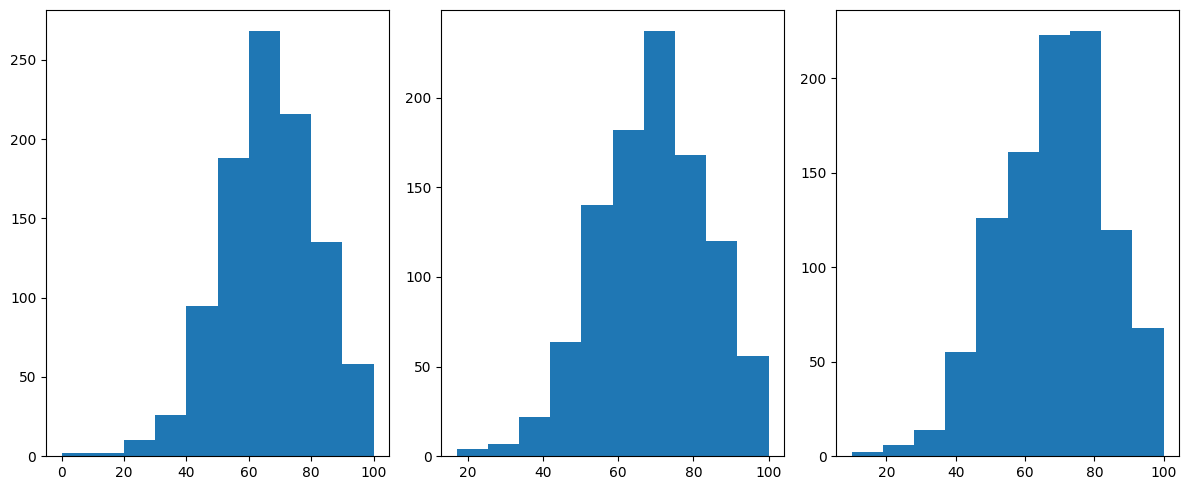

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.subplot(1,3,1)
plt.hist(df['math_score'])

plt.subplot(1,3,2)
plt.hist(df['reading_score'])

plt.subplot(1,3,3)
plt.hist(df['writing_score'])

plt.tight_layout()
plt.show()

# **2.Relationship (Scatter Plot)**

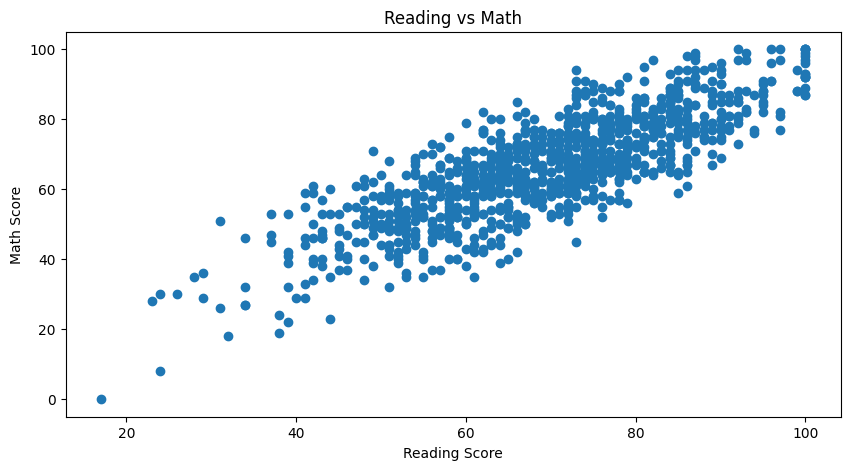

In [14]:
plt.figure(figsize=(10,5))
plt.scatter(df['reading_score'], df['math_score'])
plt.xlabel("Reading Score")
plt.ylabel("Math Score")
plt.title("Reading vs Math")
plt.show()

# **3. Writing vs Math**

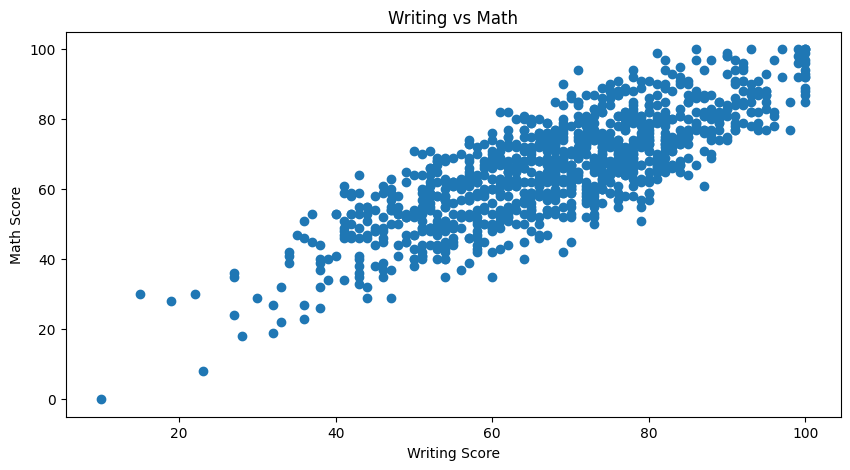

In [16]:
plt.figure(figsize=(10,5))
plt.scatter(df['writing_score'], df['math_score'])
plt.xlabel("Writing Score")
plt.ylabel("Math Score")
plt.title("Writing vs Math")
plt.show()

# **4. Correlation (Important)**

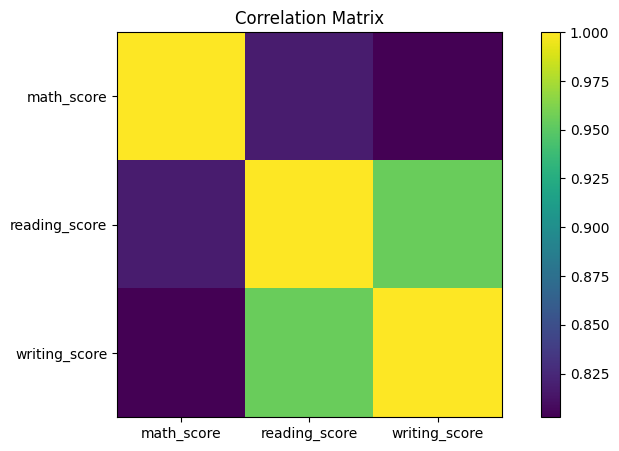

In [18]:
corr = df[['math_score','reading_score','writing_score']].corr()

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.imshow(corr)
plt.colorbar()
plt.xticks([0,1,2], corr.columns)
plt.yticks([0,1,2], corr.columns)
plt.title("Correlation Matrix")
plt.show()

# **Feature Selection**

In [19]:
X = df[['reading_score', 'writing_score']]
y = df['math_score']

# **Train-Test Split**

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# **Model Training**

In [21]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

# **Prediction**

In [22]:
y_pred = model.predict(X_test)

# **Visualization (Actual vs Predicted)**

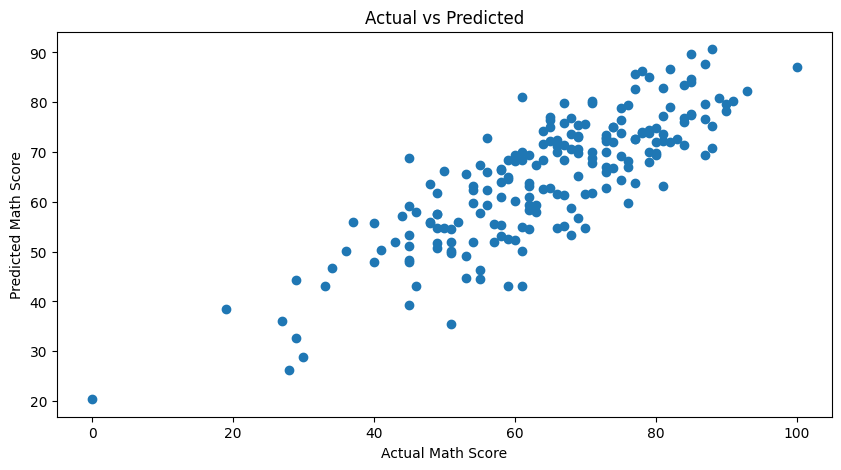

In [24]:
plt.figure(figsize=(10,5))

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Math Score")
plt.ylabel("Predicted Math Score")
plt.title("Actual vs Predicted")

plt.show()

# **Model Evaluation**

In [25]:
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R2 Score:", r2)

Mean Squared Error: 77.24297821278955
R2 Score: 0.6825697127424626


**INSIGHTS FROM MACHINE LEARNING MODEL**

1. There is a strong positive correlation between reading, writing, and math scores.

2. Students who perform well in reading and writing tend to score higher in mathematics.

3. The Linear Regression model effectively predicts math scores based on reading and writing performance.

4. The R2 score indicates that the model explains a significant portion of the variance in math scores.

5. The model can be used to estimate student performance and identify areas for improvement.